# Granger Causality Analysis: Which Comes First, Chicken or Eggs?

## Research Question

The phrase *"Which came first, the chicken or the egg?"* is usually treated as a philosophical puzzle.

In economics, however, we can ask a related question:

> Do changes in chicken prices help predict future egg prices?
>
> Or do egg prices help predict future chicken prices?

To investigate this, we use **Granger causality**, a statistical framework developed by economist Clive Granger.

A variable **X Granger-causes Y** if past values of X contain useful information for forecasting Y beyond what Y's own history already provides.

This notebook demonstrates a complete Granger causality workflow:

1. Collect data
2. Explore the time series
3. Test for stationarity
4. Transform the data if necessary
5. Select an appropriate lag length
6. Estimate a Vector Autoregression (VAR)
7. Run Granger causality tests
8. Visualize dynamic effects using impulse responses

Let's begin.

## 1. Setup and Imports

We start by installing and importing the libraries required for time-series analysis.

The key packages are:

- **pandas** for data handling
- **matplotlib** for visualization
- **statsmodels** for econometric models and hypothesis testing
- **pandas-datareader** for downloading data directly from the Federal Reserve Economic Data (FRED) database

The goal is to create a fully reproducible workflow with publicly available data.

In [1]:
!pip install pandas-datareader statsmodels -q

import warnings
warnings.filterwarnings("ignore")

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pandas_datareader import data as web

from statsmodels.tsa.stattools import (
    adfuller,
    grangercausalitytests
)

from statsmodels.tsa.api import VAR

## 2. Downloading Chicken and Egg Price Data

Rather than using simulated data, we use real price data from FRED.

The series represent consumer prices for:

- Chicken
- Eggs

Using real-world data makes the analysis more interesting because these products are economically linked through production costs, supply chains, and consumer demand.

Our first task is simply to retrieve the data and combine both series into a single DataFrame.

### Inspecting the Data

A quick inspection allows us to verify:

- The data downloaded correctly
- Dates are aligned
- No obvious missing values exist

Always inspect raw data before proceeding to analysis.

In [2]:
# Chicken price
chicken = web.DataReader(
    "APU0000706111",
    "fred",
    start="2000-01-01"
)

# Egg price
eggs = web.DataReader(
    "APU0000708111",
    "fred",
    start="2000-01-01"
)

df = chicken.join(eggs).dropna()

df.columns = [
    "chicken_price",
    "egg_price"
]

df.head()

,chicken_price,egg_price
DATE,,
2000-01-01,1.059,0.975
2000-02-01,1.046,0.962
2000-03-01,1.064,0.931
2000-04-01,1.069,0.939
2000-05-01,1.052,0.852


## 3. Exploratory Data Analysis

Before running any statistical tests, it is important to visualize the data.

Plots help answer several questions:

- Do prices trend upward over time?
- Do both series move together?
- Are there visible shocks or structural changes?

Many econometric problems become obvious once the data are plotted.

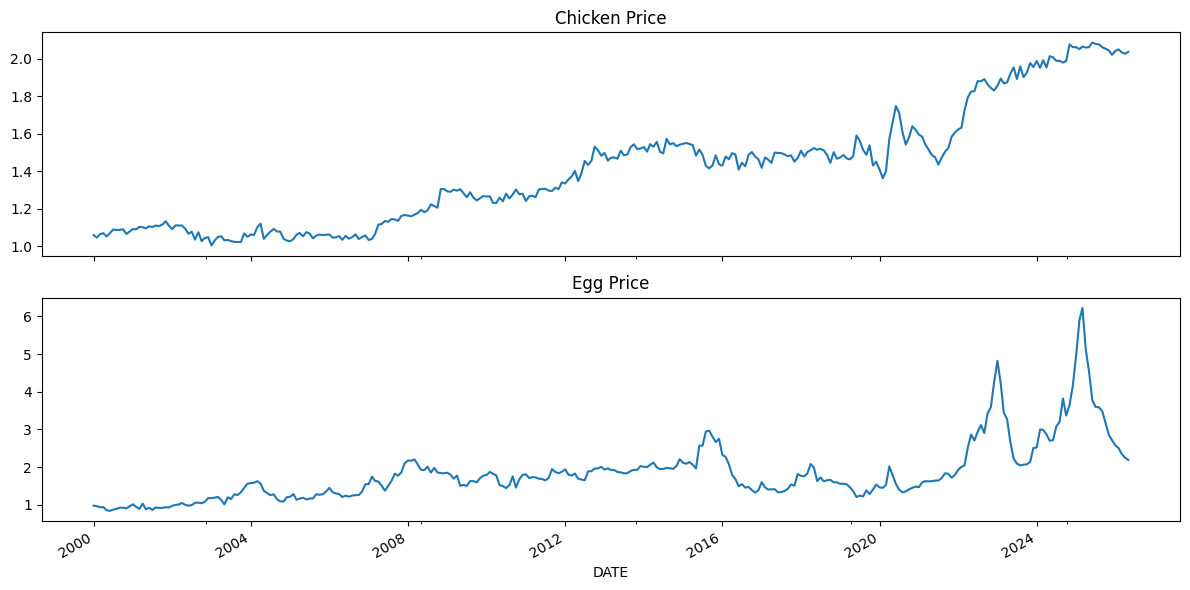

In [3]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,6),
    sharex=True
)

df["chicken_price"].plot(ax=ax[0])
ax[0].set_title("Chicken Price")

df["egg_price"].plot(ax=ax[1])
ax[1].set_title("Egg Price")

plt.tight_layout()
plt.show()

## 4. Testing for Stationarity

Most time-series methods assume that the statistical properties of a series remain stable over time.

This property is called **stationarity**.

A non-stationary series often exhibits:

- Trends
- Persistent growth
- Changing variance

Running Granger causality on non-stationary data can produce misleading results.

We therefore use the **Augmented Dickey-Fuller (ADF) test**.

### Hypotheses

**Null hypothesis (H₀):**
The series contains a unit root and is non-stationary.

**Alternative hypothesis (H₁):**
The series is stationary.

A p-value below 0.05 generally suggests stationarity.

In [4]:
def adf_test(series,name):

    result = adfuller(series.dropna())

    print("\n",name)
    print("-"*40)
    print("ADF Statistic:",result[0])
    print("p-value:",result[1])

    if result[1] < 0.05:
        print("Stationary")
    else:
        print("Non-stationary")

### Testing the Raw Price Series

Let's see whether chicken and egg prices are stationary in levels.

Economic price data often contain long-run trends, so we expect the null hypothesis of non-stationarity to be difficult to reject.

In [5]:
adf_test(
    df["chicken_price"],
    "Chicken"
)

adf_test(
    df["egg_price"],
    "Eggs"
)



 Chicken
----------------------------------------
ADF Statistic: 0.2253523889586929
p-value: 0.9736482180195586
Non-stationary

 Eggs
----------------------------------------
ADF Statistic: -2.891278145876923
p-value: 0.04637167171145504
Stationary


## 5. Transforming the Data

If a series is non-stationary, a common remedy is **first differencing**.

Instead of analyzing prices directly, we analyze price changes:

ΔPriceₜ = Priceₜ − Priceₜ₋₁

This removes long-run trends and often produces a stationary series suitable for VAR and Granger causality analysis.

In [6]:
df_diff = df.diff().dropna()

df_diff.head()

,chicken_price,egg_price
DATE,,
2000-02-01,-0.013,-0.013
2000-03-01,0.018,-0.031
2000-04-01,0.005,0.008
2000-05-01,-0.017,-0.087
2000-06-01,0.017,-0.014


### Verifying Stationarity After Differencing

After differencing, we repeat the ADF tests.

Our objective is to confirm that both transformed series are now stationary.

If stationarity is achieved, we can proceed safely to model estimation.

In [7]:
adf_test(
    df_diff["chicken_price"],
    "Chicken Differenced"
)

adf_test(
    df_diff["egg_price"],
    "Eggs Differenced"
)


 Chicken Differenced
----------------------------------------
ADF Statistic: -11.909043680580746
p-value: 5.35042893681404e-22
Stationary

 Eggs Differenced
----------------------------------------
ADF Statistic: -7.029690401555219
p-value: 6.231611249481189e-10
Stationary


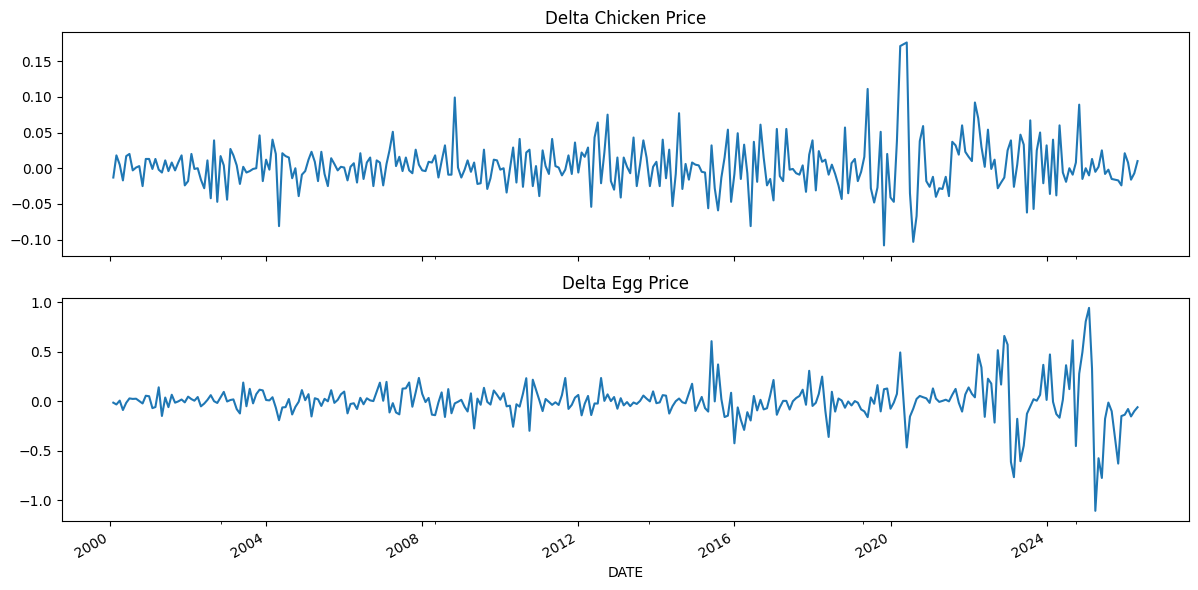

In [8]:
fig, ax = plt.subplots(
    2,
    1,
    figsize=(12,6),
    sharex=True
)

df_diff["chicken_price"].plot(ax=ax[0])

ax[0].set_title(
    "Delta Chicken Price"
)

df_diff["egg_price"].plot(ax=ax[1])

ax[1].set_title(
    "Delta Egg Price"
)

plt.tight_layout()
plt.show()

## 7. Selecting the VAR Lag Length

Granger causality relies on a Vector Autoregression (VAR).

A VAR predicts each variable using:

- Its own past values
- Past values of the other variables

A critical decision is determining how many past periods (lags) to include.

Too few lags:
- Important information is omitted.

Too many lags:
- The model becomes unnecessarily complex.

We use the Bayesian Information Criterion (BIC), which balances model fit against complexity.

In [9]:
model = VAR(df_diff)

lag_selection = model.select_order(12)

print(
    lag_selection.summary()
)

 VAR Order Selection (* highlights the minimums)  
       AIC         BIC         FPE         HQIC   
--------------------------------------------------
0       -9.956      -9.932   4.743e-05      -9.946
1       -10.02     -9.950*   4.433e-05     -9.994*
2       -10.01      -9.890   4.481e-05      -9.964
3       -10.00      -9.832   4.520e-05      -9.936
4       -10.01      -9.793   4.478e-05      -9.925
5       -10.01      -9.739   4.499e-05      -9.901
6       -10.02      -9.701   4.450e-05      -9.892
7       -10.02      -9.656   4.430e-05      -9.877
8      -10.04*      -9.626  4.346e-05*      -9.877
9       -10.04      -9.568   4.384e-05      -9.849
10      -10.03      -9.514   4.406e-05      -9.824
11      -10.03      -9.466   4.404e-05      -9.805
12      -10.03      -9.413   4.421e-05      -9.782
--------------------------------------------------


/usr/local/lib/python3.12/dist-packages/statsmodels/tsa/base/tsa_model.py:473: ValueWarning: A date index has been provided, but it has no associated frequency information and so will be ignored when e.g. forecasting.
  self._init_dates(dates, freq)


## 8. Estimating the VAR Model

Using the optimal lag length selected by BIC, we estimate a Vector Autoregression.

The VAR captures the dynamic relationship between chicken-price changes and egg-price changes.

The estimated coefficients describe how shocks propagate through the system over time.

In [10]:
optimal_lag = (
    lag_selection
    .selected_orders["bic"]
)

print(
    "Optimal lag:",
    optimal_lag
)

var_model = model.fit(
    optimal_lag
)

print(
    var_model.summary()
)

Optimal lag: 1
  Summary of Regression Results   
Model:                         VAR
Method:                        OLS
Date:           Mon, 15, Jun, 2026
Time:                     13:52:02
--------------------------------------------------------------------
No. of Equations:         2.00000    BIC:                   -10.0170
Nobs:                     313.000    HQIC:                  -10.0601
Log likelihood:           696.649    FPE:                4.15404e-05
AIC:                     -10.0888    Det(Omega_mle):     4.07554e-05
--------------------------------------------------------------------
Results for equation chicken_price
                      coefficient       std. error           t-stat            prob
-----------------------------------------------------------------------------------
const                    0.003240         0.001887            1.717           0.086
L1.chicken_price        -0.042359         0.056558           -0.749           0.454
L1.egg_price             

## 9. Checking Model Stability

A VAR must be stable before its forecasts and impulse-response functions can be interpreted.

A stable VAR implies that shocks eventually dissipate rather than explode over time.

The `is_stable()` method provides a quick diagnostic.

In [11]:
print(
    "Stable:",
    var_model.is_stable()
)

Stable: True


## 10. Granger Causality: Chicken → Eggs

Our first test asks:

> Do past chicken-price changes improve forecasts of future egg-price changes?

### Hypotheses

**Null hypothesis (H₀):**
Chicken prices do not Granger-cause egg prices.

**Alternative hypothesis (H₁):**
Chicken prices do Granger-cause egg prices.

A p-value below 0.05 leads us to reject the null hypothesis.

In [12]:
result1 = var_model.test_causality(
    caused="egg_price",
    causing=["chicken_price"]
)

print(
    result1.summary()
)

Granger causality F-test. H_0: chicken_price does not Granger-cause egg_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
        0.7748          3.857   0.379 (1, np.int64(620))
--------------------------------------------------------


## 11. Granger Causality: Eggs → Chicken

Next, we reverse the direction.

We ask:

> Do past egg-price changes improve forecasts of future chicken-price changes?

Testing both directions is important because economic relationships are often bidirectional.

In [13]:
result2 = var_model.test_causality(
    caused="chicken_price",
    causing=["egg_price"]
)

print(
    result2.summary()
)

Granger causality F-test. H_0: egg_price does not Granger-cause chicken_price. Conclusion: fail to reject H_0 at 5% significance level.
Test statistic Critical value p-value         df        
--------------------------------------------------------
         1.947          3.857   0.163 (1, np.int64(620))
--------------------------------------------------------


## 12. Interpreting the Results

The summary below converts the statistical tests into a simple yes/no answer.

Remember:

- Granger causality indicates predictive usefulness.
- It does not prove true economic causation.
- External factors may influence both markets simultaneously.

Nevertheless, Granger causality is a powerful first step for investigating temporal relationships.

In [14]:
print(
    "\nChicken → Eggs:",
    "YES"
    if result1.pvalue < 0.05
    else "NO"
)

print(
    "Eggs → Chicken:",
    "YES"
    if result2.pvalue < 0.05
    else "NO"
)


Chicken → Eggs: NO
Eggs → Chicken: NO


## 13. Impulse Response Analysis

The Granger test tells us whether predictive relationships exist.

Impulse Response Functions (IRFs) go one step further:

> What happens after a sudden shock?

For example:

- If chicken prices unexpectedly rise today,
- How do egg prices respond over the next 12 months?

IRFs provide a dynamic visualization of these effects and are one of the most useful outputs of a VAR model.

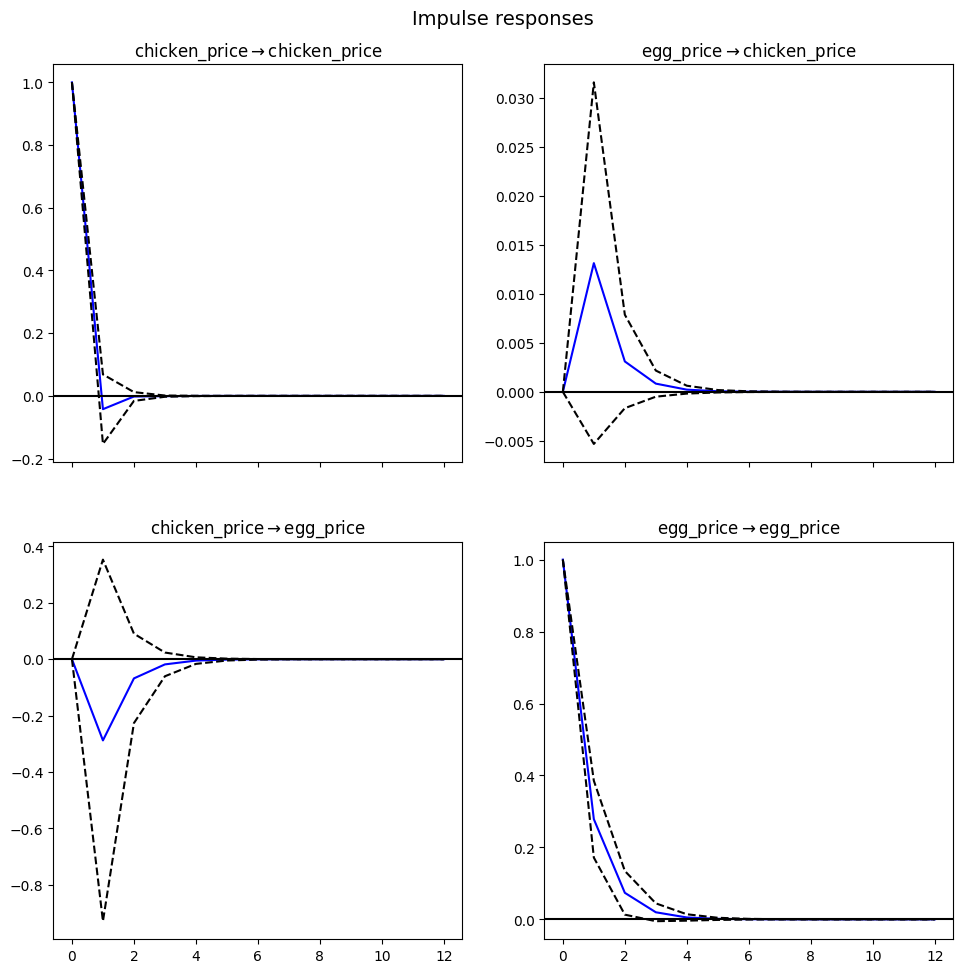

In [15]:
irf = var_model.irf(12)

irf.plot()

plt.show()

## Conclusion

In this notebook we completed a standard econometric workflow:

1. Retrieved real-world economic data
2. Tested for stationarity
3. Applied differencing where necessary
4. Selected an optimal lag length
5. Estimated a Vector Autoregression
6. Conducted Granger causality tests
7. Analyzed impulse responses

The broader lesson is that Granger causality is not about proving causation in a philosophical sense.

Instead, it helps answer a practical forecasting question:

> Does knowledge of one variable's past improve our ability to predict another variable's future?

That question lies at the heart of modern time-series analysis.